In [1]:
from google.colab import drive
import os
import shutil
import sys
from pathlib import Path

# 1. Mount Drive
# Using force_remount=True to fix potential connection issues
print("Mounting Google Drive...")
drive.mount("/content/drive", force_remount=True)

# 2. Check for zip file in likely locations
zip_filename = "heritagelens.zip"
zip_path_drive = Path("/content/drive/MyDrive") / zip_filename
zip_path_local = Path("/content") / zip_filename

target_zip = None
if zip_path_drive.exists():
    target_zip = zip_path_drive
elif zip_path_local.exists():
    target_zip = zip_path_local

# 3. Unzip if found
if target_zip:
    print(f"Found zip at: {target_zip}")
    print("Unzipping...")
    try:
        shutil.unpack_archive(str(target_zip), "/content/", "zip")
        print("Unzip complete.")
    except OSError as e:
        if e.errno == 107:
            print("Error: Transport endpoint is still not connected. Please restart the Runtime (Runtime > Restart session) and try again.")
        raise e
else:
    print(f"WARNING: {zip_filename} not found in Drive or local storage.")
    print(f"Checked: {zip_path_drive} AND {zip_path_local}")

# 4. Set ROOT and change directory
possible_root = Path("/content/heritagelens")
if possible_root.exists() and possible_root.is_dir():
    ROOT = possible_root
else:
    ROOT = Path("/content")

print(f"Project ROOT set to: {ROOT}")

# Add to sys.path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Change directory
os.chdir(ROOT)
print(f"Current working directory: {Path.cwd()}")

# List contents to verify structure
print("Root folder contents:", [x.name for x in Path.cwd().iterdir()])

Mounted at /content/drive
Found zip at: /content/drive/MyDrive/heritagelens.zip
Unzipping...
Unzip complete.
Project ROOT set to: /content/heritagelens
Current working directory: /content/heritagelens
Root folder contents: ['README.md', 'outputs', 'scripts', '.gitignore', 'notebooks', 'src', 'requirements.txt', '.git', 'data']


In [5]:
# 1. Install necessary libraries
!pip install transformers datasets torch torchvision tqdm

import sys
import warnings
from pathlib import Path

# Suppress HF token warnings which look like errors
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub")

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from tqdm import tqdm

# Handle Hugging Face Authentication (Optional)
try:
    from google.colab import userdata
    from huggingface_hub import login
    # Try to get the token (suppress errors if secrets are not defined)
    try:
        hf_token = userdata.get('HF_TOKEN')
        if hf_token:
            login(hf_token)
            print("Logged in to Hugging Face Hub.")
        else:
            print("No HF_TOKEN found. Using unauthenticated access (sufficient for public models).")
    except (ImportError, AttributeError, Exception):
        print("Using unauthenticated access to Hugging Face Hub (sufficient for public models).")
except Exception:
    pass

# Project root (when running from notebooks/ or from repo root)
ROOT = Path.cwd().parent if "notebooks" in str(Path.cwd()) else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Image transform (must match HeritageDataset; used for training and generation)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

Using unauthenticated access to Hugging Face Hub (sufficient for public models).
Using device: cuda


In [3]:
# --- 1. ENCODER (ResNet50) ---
class HeritageEncoder(nn.Module):
    def __init__(self):
        super(HeritageEncoder, self).__init__()
        resnet = models.resnet50(weights='ResNet50_Weights.DEFAULT')
        # Remove the last two layers to get spatial feature maps (7x7x2048)
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])

        # FREEZE ENCODER: As per project plan, we only train the decoder/attention
        for param in self.resnet.parameters():
            param.requires_grad = False

    def forward(self, images):
        features = self.resnet(images)  # [batch, 2048, 7, 7]
        features = features.permute(0, 2, 3, 1)  # [batch, 7, 7, 2048]
        features = features.view(features.size(0), -1, features.size(-1)) # [batch, 49, 2048]
        return features

# --- 2. ATTENTION (Bahdanau) ---
class HeritageAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(HeritageAttention, self).__init__()
        self.W = nn.Linear(decoder_dim, attention_dim)
        self.U = nn.Linear(encoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, features, hidden):
        # features: [batch, 49, 2048], hidden: [batch, 768]
        hidden_with_time = hidden.unsqueeze(1)
        score = torch.tanh(self.W(hidden_with_time) + self.U(features))
        weights = torch.softmax(self.v(score), dim=1)
        context = torch.sum(weights * features, dim=1)
        return context, weights

# --- 3. THE COMPLETE SYSTEM ---
class HeritageLens(nn.Module):
    def __init__(self, vocab_size):
        super(HeritageLens, self).__init__()
        self.encoder = HeritageEncoder()
        self.attention = HeritageAttention(encoder_dim=2048, decoder_dim=768, attention_dim=512)
        self.gpt2 = GPT2LMHeadModel.from_pretrained('gpt2')

        # Bridge to map visual context to GPT2 hidden size
        self.visual_projection = nn.Linear(2048, 768)

    def forward(self, images, captions, labels=None):
        # captions: input_ids [batch, seq_len]. labels: same shape, -100 for padding (optional)
        # Get visual features: [batch, 49, 2048]
        features = self.encoder(images)

        # For training, we use global average pooling for the initial visual context
        visual_context = self.visual_projection(features.mean(dim=1))

        # Get GPT2 word embeddings
        inputs_embeds = self.gpt2.transformer.wte(captions)

        # Inject visual context into the word embeddings
        combined_embeds = inputs_embeds + visual_context.unsqueeze(1)

        # Pass through GPT2 (use labels for loss so padding can be masked with -100)
        loss_labels = labels if labels is not None else captions
        outputs = self.gpt2(inputs_embeds=combined_embeds, labels=loss_labels)
        return outputs.loss, outputs.logits

Starting Professional Training on A100...


Epoch 1/20 [Train]:   0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipython-input-3936767570.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validating:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist


Epoch 1 Summary: Train Loss: 1.8809 | Val Loss: 1.2722 | BLEU-4: 0.3756


Validating: 100%|██████████| 4/4 [00:07<00:00,  1.91s/it]



Epoch 2 Summary: Train Loss: 1.6086 | Val Loss: 1.0546 | BLEU-4: 0.4360


...


Epoch 18 Summary: Train Loss: 0.6796 | Val Loss: 0.3287 | BLEU-4: 0.6044


Validating: 100%|██████████| 4/4 [00:07<00:00,  1.92s/it]



Epoch 19 Summary: Train Loss: 0.7103 | Val Loss: 0.2392 | BLEU-4: 0.6445


Validating: 100%|██████████| 4/4 [00:07<00:00,  1.93s/it]



Epoch 20 Summary: Train Loss: 0.6693 | Val Loss: 0.7385 | BLEU-4: 0.5393


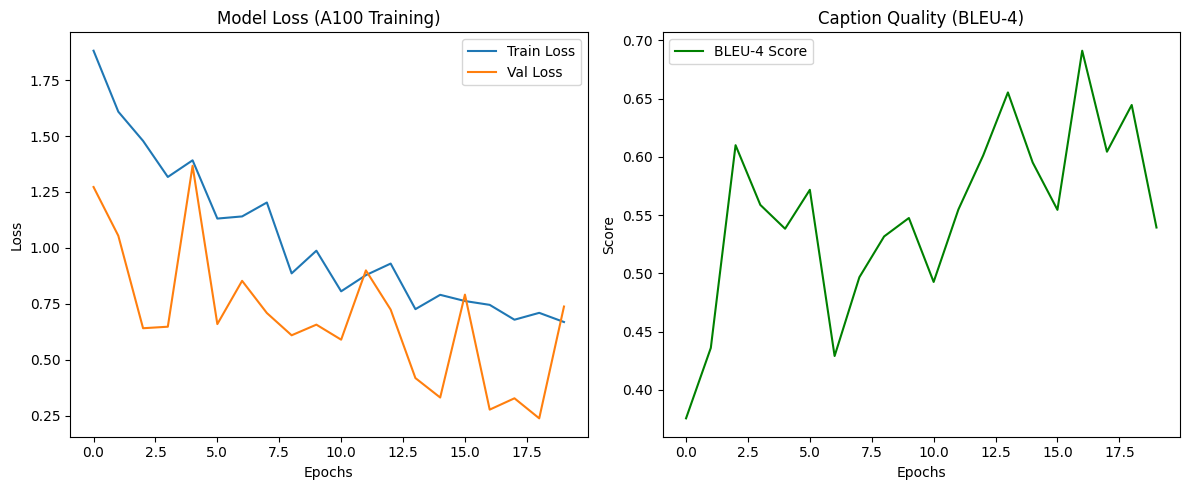

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from nltk.translate.bleu_score import sentence_bleu

# --- CONFIGURATION ---
NUM_EPOCHS = 20  # Increased for better cultural recognition
history = {"train_loss": [], "val_loss": [], "val_bleu": []}

print(f"Starting Professional Training on A100...")

for epoch in range(NUM_EPOCHS):
    # 1. TRAINING PHASE
    model.train()
    total_train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

    for batch in pbar:
        if batch is None: continue
        images, input_ids, _, labels = [x.to(device) for x in batch]

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss, logits = model(images, input_ids, labels=labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    history["train_loss"].append(avg_train_loss)


   # 2. VALIDATION PHASE
    model.eval()
    total_val_loss = 0
    bleu_scores = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Validating"):
            if batch is None: continue
            images, input_ids, _, labels = [x.to(device) for x in batch]

            # Using the updated autocast syntax to remove the FutureWarning
            with torch.amp.autocast('cuda'):
                loss, logits = model(images, input_ids, labels=labels)

            total_val_loss += loss.item()

            # --- FIX: Filter out -100 before decoding ---
            preds = torch.argmax(logits, dim=-1)
            for i in range(len(preds)):
                # Filter labels to remove -100 (padding) values
                clean_label_ids = labels[i][labels[i] != -100].tolist()

                reference = [tokenizer.decode(clean_label_ids, skip_special_tokens=True).split()]
                candidate = tokenizer.decode(preds[i], skip_special_tokens=True).split()

                # BLEU-4 score
                score = sentence_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25))
                bleu_scores.append(score)

    avg_val_loss = total_val_loss / len(val_loader)
    avg_bleu = np.mean(bleu_scores)

    history["val_loss"].append(avg_val_loss)
    history["val_bleu"].append(avg_bleu)

    print(f"\nEpoch {epoch+1} Summary: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | BLEU-4: {avg_bleu:.4f}")

# --- 3. PLOT RESULTS FOR RESEARCH PAPER ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Model Loss (A100 Training)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot BLEU Score
plt.subplot(1, 2, 2)
plt.plot(history["val_bleu"], color='green', label="BLEU-4 Score")
plt.title("Caption Quality (BLEU-4)")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
def generate_caption(image_path, model, tokenizer, max_length=30):
    """Generate a caption for an image. Uses transform from cell 0."""
    model.eval()

    # 1. Load and preprocess the image (transform defined in cell 0)
    from PIL import Image
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        return f"Error opening image: {e}"

    image = transform(image).unsqueeze(0).to(device)

    # 2. Start with the "start" token
    input_ids = torch.tensor([[tokenizer.bos_token_id]]).to(device)

    generated_caption = []

    with torch.no_grad():
        for _ in range(max_length):
            # Get the model's prediction
            loss, logits = model(image, input_ids)

            # Take the last word predicted
            next_token_logits = logits[:, -1, :]
            next_token_id = torch.argmax(next_token_logits, dim=-1).unsqueeze(0)

            # If the model predicts "End of Text", stop generating
            if next_token_id == tokenizer.eos_token_id:
                break

            generated_caption.append(next_token_id.item())

            # Append predicted word to input for the next step
            input_ids = torch.cat([input_ids, next_token_id], dim=-1)

    # Convert IDs back to actual Nepali/English words
    return tokenizer.decode(generated_caption, skip_special_tokens=True)

# --- TEST IT OUT ---
test_image_path = "/content/Screenshot 2026-02-07 at 1.27.28 PM.png"
print(f"Generating caption for: {test_image_path}")
caption = generate_caption(test_image_path, model, tokenizer)
print("Generated Caption:", caption)

Generating caption for: /content/Screenshot 2026-02-07 at 1.27.28 PM.png
Generated Caption: 
The Buddha Temple in Nepal's Kathmandu Valley.

The Buddha Temple in Nepal's Kathmandu Valley.

The Buddha Temple
